# Digital Signal Processing - Session 7

## Limitations of the Fast Fourier Transform

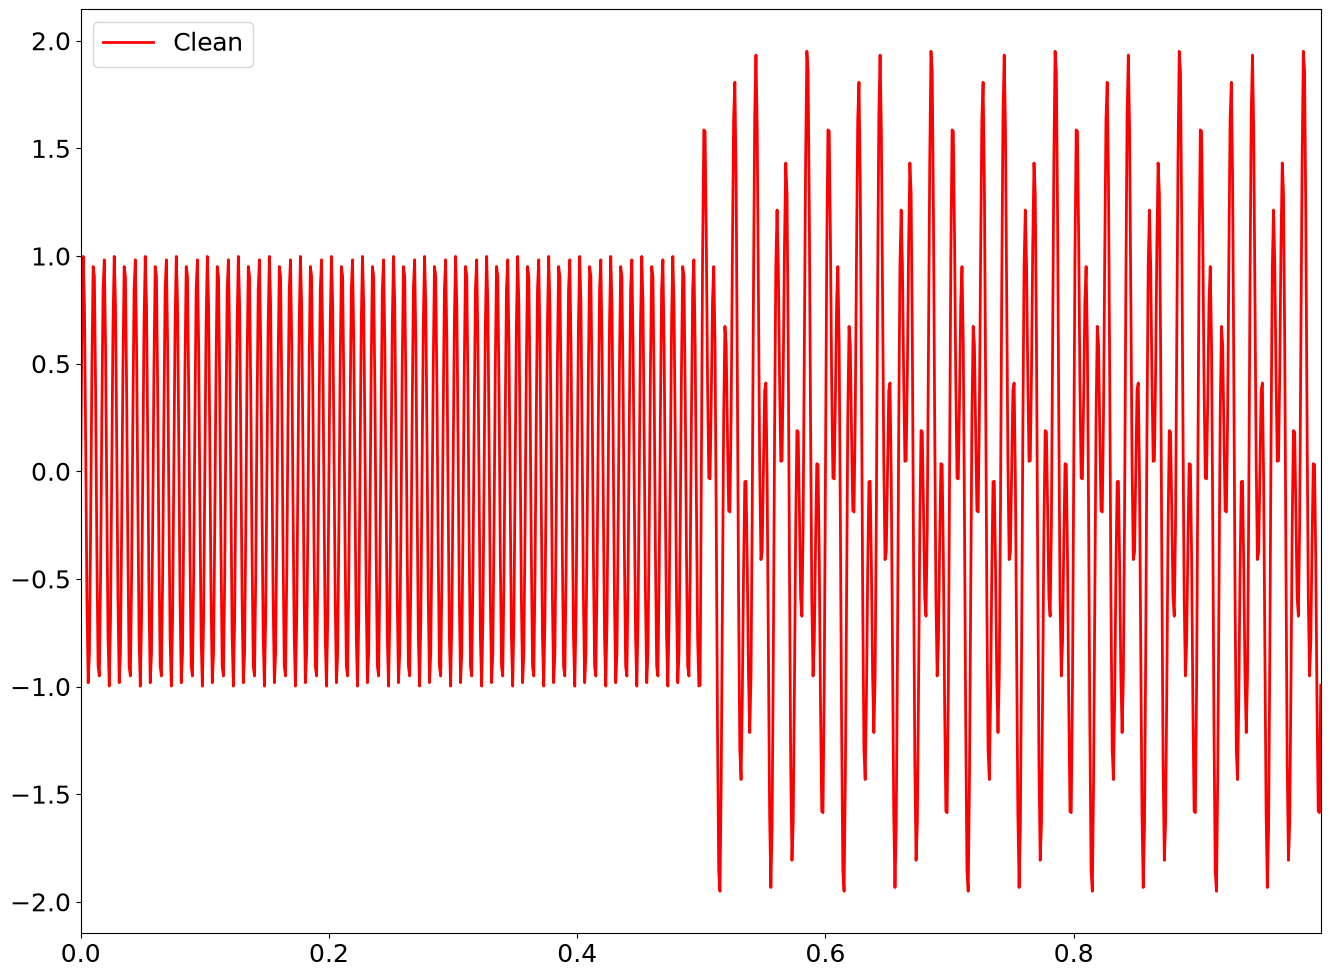

In [15]:
#Audio Signal Denosing Using FFT
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=[16,12]
plt.rcParams.update({'font.size':18})
# Create a simple signal with two frequencies
Fs = 1000 # The sampling frequency is 1kHz
dt = 1/Fs # 0.001
t = np.arange(0,1,dt)
# Sum of two sin waves (50Hz and 120Hz)
x = np.sin(2*np.pi*50*t) + np.sin(2*np.pi*120*t)
# x_clean = x
# x_clean[:(int(len(t)/2)-1)] = 0

x1 = np.sin(2*np.pi*50*t) 
x1[:(int(len(t)/2)-1)] = 0
x2 = np.sin(2*np.pi*120*t)
# x2[int(3/4*len(t)):] = 0
x_clean = x1+x2

# x = x + 0.0*np.random.randn(len(t))
x_clean = x_clean + 0*np.random.randn(len(t))
# plt.plot(t,x,color='c',linewidth=1.5,label='Noisy')
plt.plot(t,x_clean, color='r',linewidth=2,label='Clean')
plt.xlim(t[0],t[-1])
plt.legend()
plt.show()

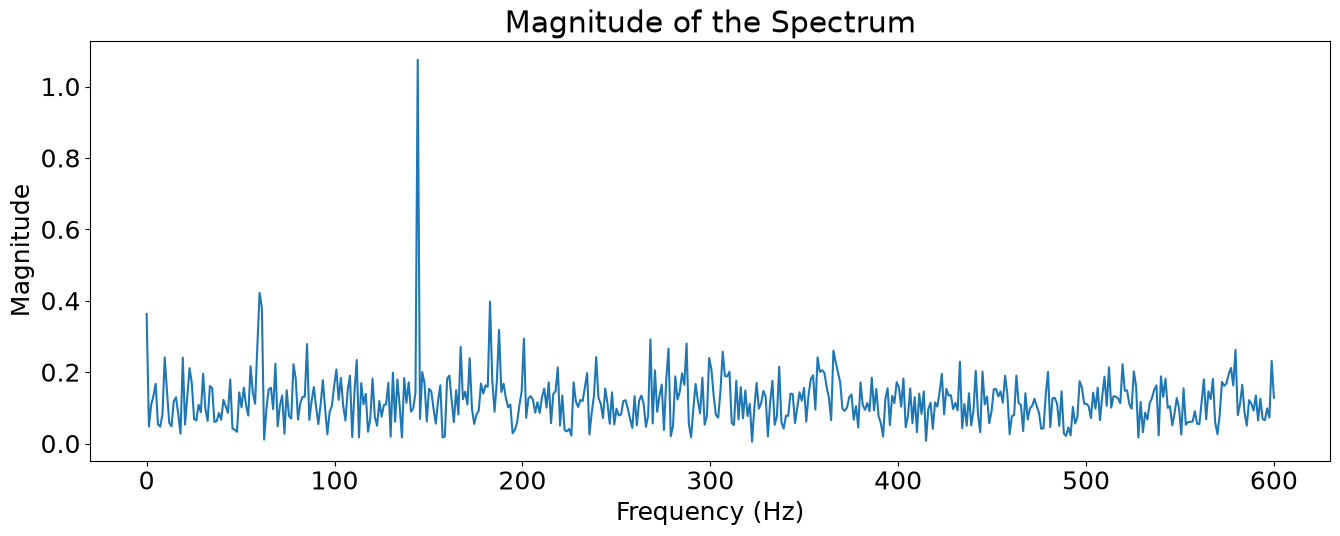

In [14]:
# Generate freqeuncy axis
n = np.size(t)
# We just need half of the samples in frequency domain since the signal is real-valued
fr = (fs/2)*np.linspace(0,1,int(n/2))
# Compute FFT of x_clean
X = fft(x_clean)
# Magnitude of the FFT
X_mag = 2/n * np.abs(X[0:np.size(fr)])

plt.subplot(2,1,2)
plt.plot(fr, X_mag)
plt.title('Magnitude of the Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.show()

## The Short Time Fourier Transform 

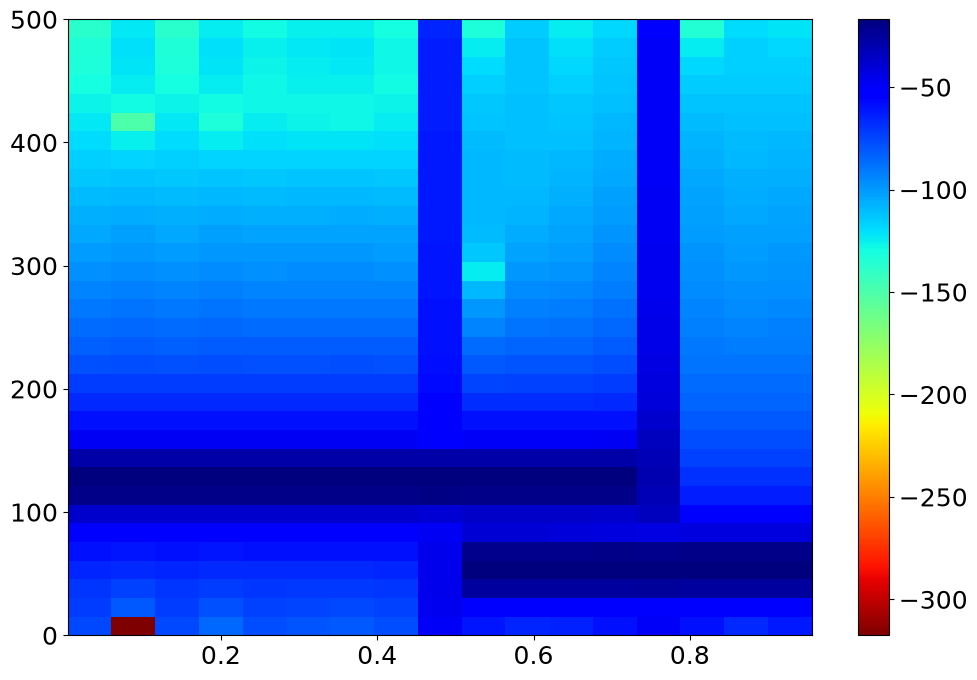

In [31]:
#spectrogram
import numpy as np
from IPython.display import Audio
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=[12,8]
plt.rcParams.update({'font.size':18})

Fs = 1000 # The sampling frequency is 1kHz
dt = 1/Fs # 0.001
t = np.arange(0,1,dt)
# Sum of two sin waves (50Hz and 120Hz)
x1 = np.sin(2*np.pi*50*t)
x1[:(int(len(t)/2)-1)] = 0
x2 = np.sin(2*np.pi*120*t)
x2[(int(3*len(t)/4)-1):] = 0
x_clean = x1+x2

# Fs = 1000
# dt = 1/Fs
# t = np.arange(0,2,dt)
# f0 = 50
# f1 = 250
# t1 = 2
# x = np.cos(2*np.pi*t*(f0 + (f1-f0)*np.power(t,2)/(3*t1**2)))

plt.specgram(x_clean, NFFT=64, Fs=1/dt, noverlap=8, cmap='jet_r')
plt.colorbar()
plt.show()

## Wavelets Transforms

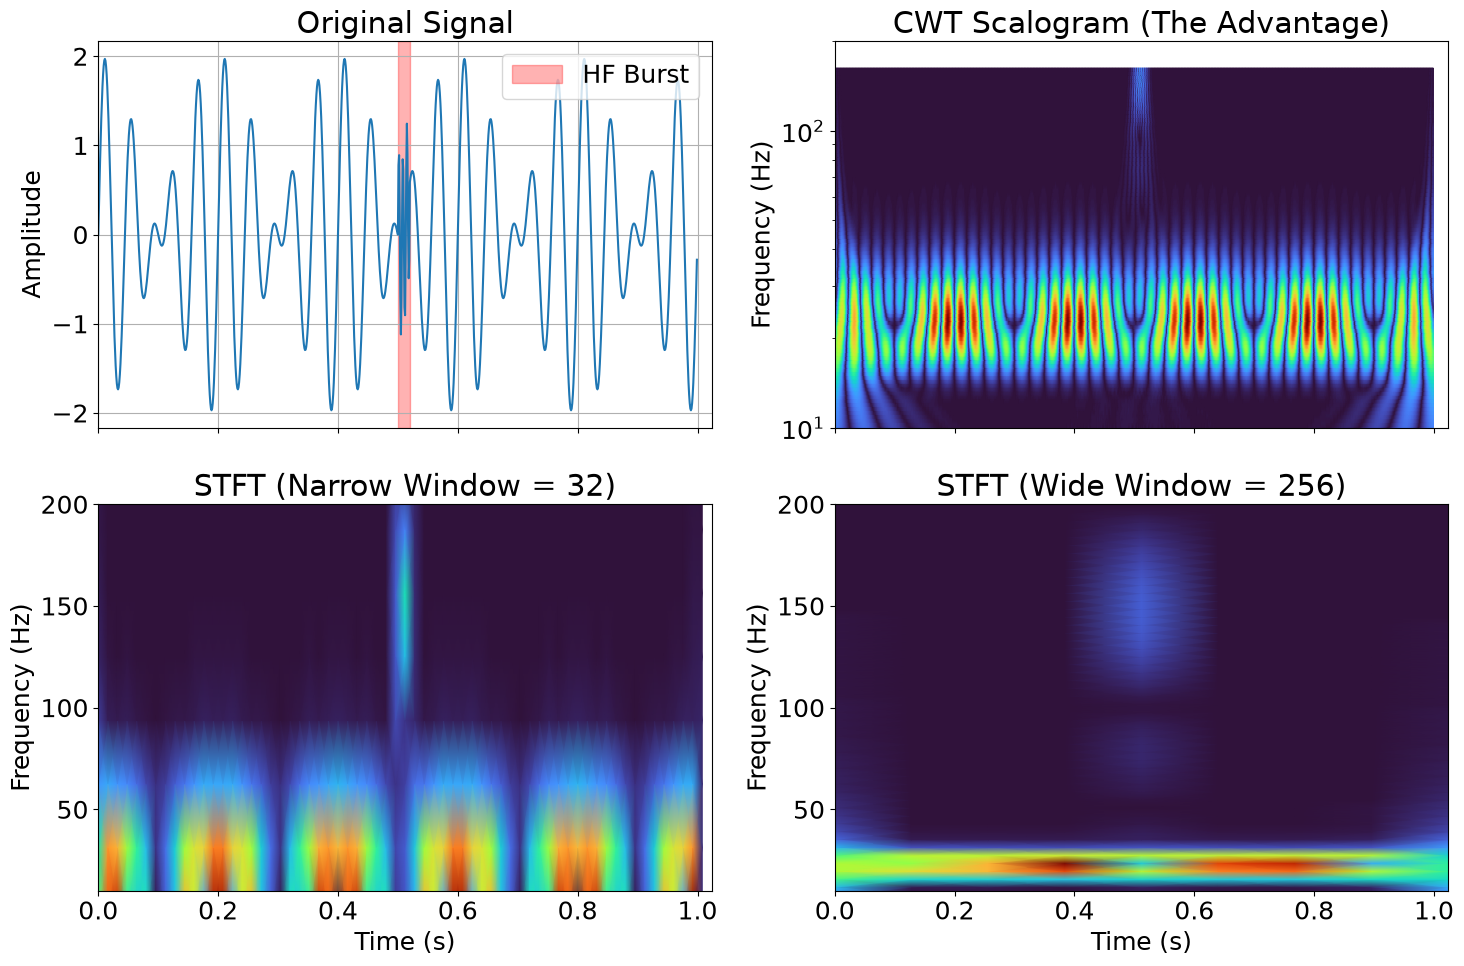

In [ ]:
import scipy.signal as sp_signal
import pywt

fs = 1000  # Sampling frequency
t = np.linspace(0, 1.0, fs, endpoint=False) # Time vector for 1 second

sig_low_1 = np.sin(2 * np.pi * 20 * t)
sig_low_2 = np.sin(2 * np.pi * 25 * t)

# Event: A very short high-frequency burst (only 20ms long)
sig_high_burst = np.zeros_like(t)
burst_start_index = 500  # 0.5s
burst_end_index = 520    # 0.52s
sig_high_burst[burst_start_index:burst_end_index] \
= np.sin(2 * np.pi * 150 * t[burst_start_index:burst_end_index])

# Final signal
signal = sig_low_1 + sig_low_2 + sig_high_burst

fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharex=True)

# The Signal
axs[0, 0].plot(t, signal)
axs[0, 0].set_title('Original Signal')
axs[0, 0].set_ylabel('Amplitude')
axs[0, 0].grid(True)
axs[0, 0].axvspan(0.5, 0.52, color='red', alpha=0.3, label='HF Burst')
axs[0, 0].legend(loc='upper right')

# STFT (Narrow Window)
# Good time resolution, bad frequency resolution
window_size_narrow = 32  # ~32ms window
f_narrow, t_narrow, Zxx_narrow = sp_signal.stft(signal, fs=fs, \
                                                nperseg=window_size_narrow, noverlap=window_size_narrow//2)

# STFT (Narrow Window)
axs[1, 0].pcolormesh(t_narrow, f_narrow, np.abs(Zxx_narrow), cmap='turbo', shading='gouraud')
axs[1, 0].set_title('STFT (Narrow Window = 32)')
axs[1, 0].set_ylabel('Frequency (Hz)')
axs[1, 0].set_xlabel('Time (s)')
axs[1, 0].set_ylim(10, 200)

# STFT (Wide Window)
# Bad time resolution, good frequency resolution
window_size_wide = 256  # ~256ms window
f_wide, t_wide, Zxx_wide = sp_signal.stft(signal, fs=fs,\
                                          nperseg=window_size_wide, noverlap=window_size_wide//2)

# STFT (Wide Window)
axs[1, 1].pcolormesh(t_wide, f_wide, np.abs(Zxx_wide), cmap='turbo', shading='gouraud')
axs[1, 1].set_title('STFT (Wide Window = 256)')
axs[1, 1].set_ylabel('Frequency (Hz)')
axs[1, 1].set_xlabel('Time (s)')
axs[1, 1].set_ylim(10, 200)

# CWT Analysis
wavelet = 'morl'
dt = 1.0 / fs
# A range of scales to cover 10Hz to 200Hz
scales = np.logspace(np.log10(fs/200), np.log10(fs/10), 100)
coefficients, frequencies = pywt.cwt(signal, scales, wavelet, dt)

# CWT (The "Correct" View)
axs[0, 1].pcolormesh(t, frequencies, np.abs(coefficients), \
                     cmap='turbo', shading='gouraud')
axs[0, 1].set_title('CWT Scalogram (The Advantage)')
axs[0, 1].set_ylabel('Frequency (Hz)')
axs[0, 1].set_ylim(10, 200)
axs[0, 1].set_yscale('log')

plt.tight_layout()
plt.show()


## Design of Digital Filters FIR

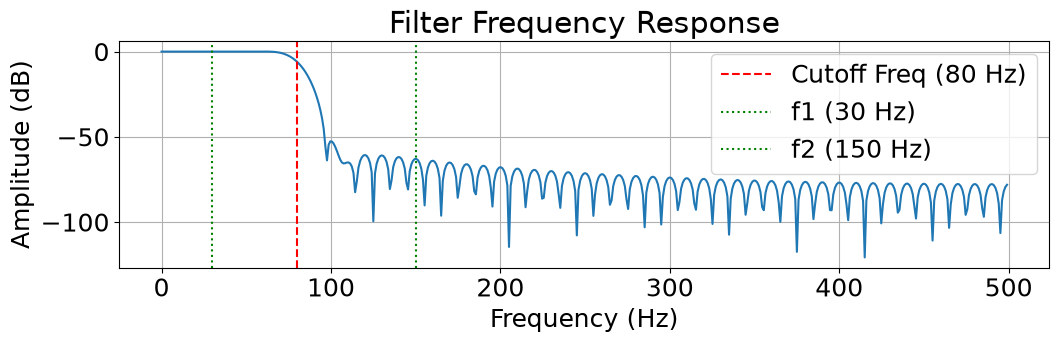

In [44]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt


fs = 1000      # Sampling frequency (Hz)
t = np.arange(0, 1, 1/fs) # Time vector (1 second duration)

f1 = 30        # Frequency 1 (low, 30 Hz) - KEEP
f2 = 150       # Frequency 2 (high, 150 Hz) - REMOVE

# Create the combined signal
signal_original = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

cutoff_freq = 80  # Cutoff frequency (Hz)

numtaps = 101
b = signal.firwin(numtaps,
                  cutoff_freq,
                  window='hamming',
                  fs=fs,
                  pass_zero='lowpass')

signal_filtered = signal.filtfilt(b, 1, signal_original)

# Plot 
w, h = signal.freqz(b, 1, fs=fs)
plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(w, 20 * np.log10(np.abs(h)))
plt.axvline(cutoff_freq, color='red', linestyle='--', label='Cutoff Freq (80 Hz)')
plt.axvline(f1, color='green', linestyle=':', label='f1 (30 Hz)')
plt.axvline(f2, color='green', linestyle=':', label='f2 (150 Hz)')
plt.title('Filter Frequency Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')
plt.legend()
plt.grid(True)

(0.0, 0.1)

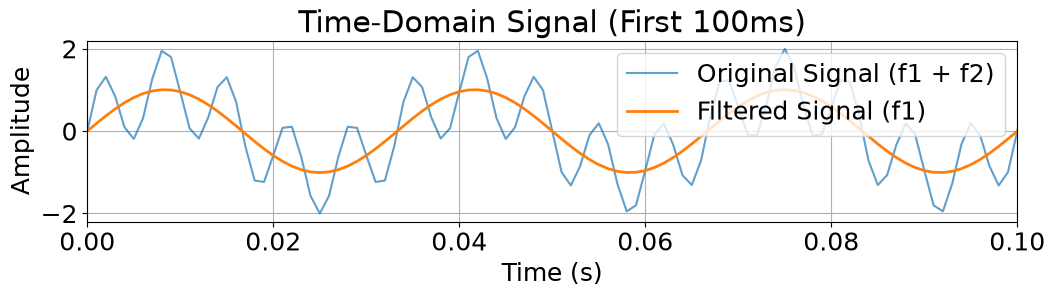

In [45]:
plt.subplot(3, 1, 2)
plt.plot(t, signal_original, label='Original Signal (f1 + f2)', alpha=0.7)
plt.plot(t, signal_filtered, label='Filtered Signal (f1)', linewidth=2)
plt.title('Time-Domain Signal (First 100ms)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.1) # Show only the first 100ms to see the waves

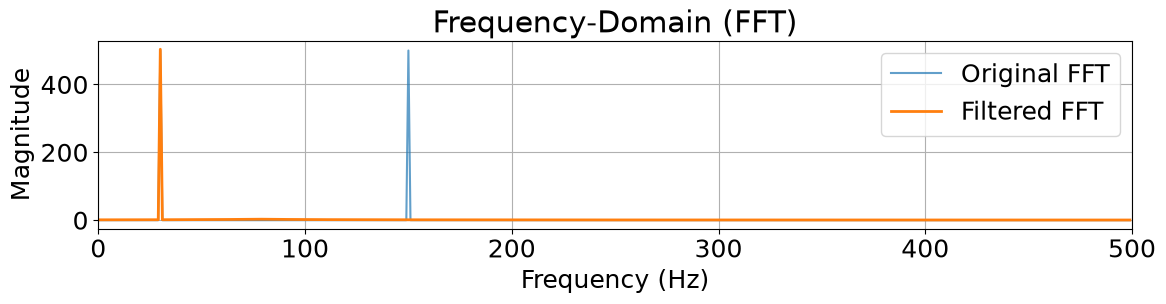

In [46]:
N = len(t)
freqs = np.fft.fftfreq(N, 1/fs)
fft_original = np.abs(np.fft.fft(signal_original))
fft_filtered = np.abs(np.fft.fft(signal_filtered))

# only plot the positive frequencies
positive_freqs = freqs[:N//2]
positive_fft_original = fft_original[:N//2]
positive_fft_filtered = fft_filtered[:N//2]

plt.subplot(3, 1, 3)
plt.plot(positive_freqs, positive_fft_original, label='Original FFT', alpha=0.7)
plt.plot(positive_freqs, positive_fft_filtered, label='Filtered FFT', linewidth=2)
plt.title('Frequency-Domain (FFT)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True)
plt.xlim(0, fs/2) # Show up to Nyquist frequency

plt.tight_layout()
plt.show()